Processing mPFC - Control
Processing mPFC - 3D
Processing mPFC - 7D
Processing mPFC - Res
Processing mPFC - Sus
Processing DRN - Control
Processing DRN - 3D
Processing DRN - 7D
Processing DRN - Res
Processing DRN - Sus
Processing Stri - Control
Processing Stri - 3D
Processing Stri - 7D
Processing Stri - Res
Processing Stri - Sus
Processing HIP - Control
Processing HIP - 3D
Processing HIP - 7D
Processing HIP - Res
Processing HIP - Sus
Processing VTA - Control
Processing VTA - 3D
Processing VTA - 7D
Processing VTA - Res
Processing VTA - Sus


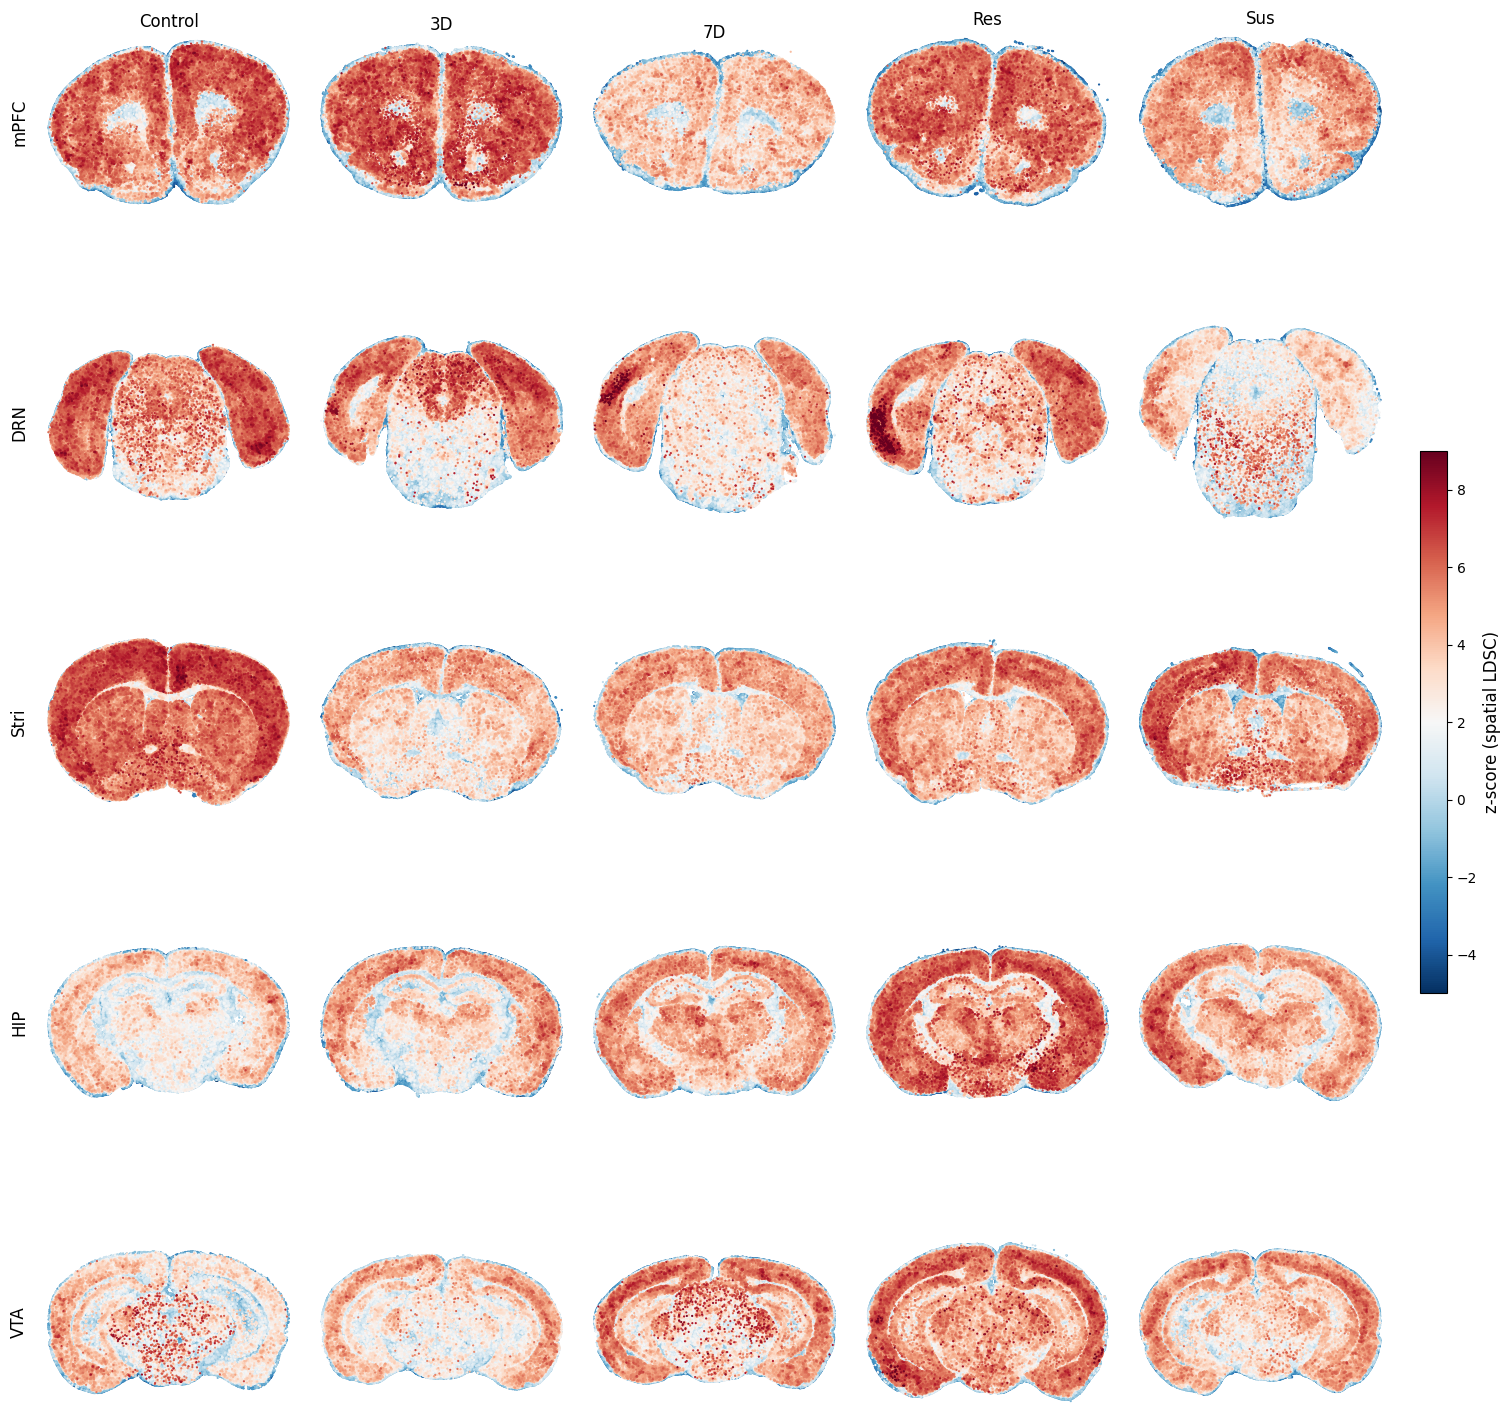

In [9]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# =========================
# 参数
# =========================
BASE_DIR = "/biostack/home/suchenyi/gsmap"

REGIONS = ["mPFC", "DRN", "Stri", "HIP", "VTA"]
CONDITIONS = ["Control", "3D", "7D", "Res", "Sus"]
TRAITS = ["MDD"]

# =========================
# 读取 spatial LDSC 结果
# =========================
def load_ldsc(region, condition, trait):
    dfs = []

    for rep in ["rep1", "rep2"]:
        path = (
            f"{BASE_DIR}/{region}_{condition}_{rep}/spatial_ldsc/"
            f"{region}_{condition}_{rep}_{trait}.csv.gz"
        )

        if not os.path.exists(path):
            continue

        df = pd.read_csv(path)
        df["spot"] = df["spot"].astype(str)

        dfs.append(
            df[["spot", "z"]].rename(columns={"z": f"z_{rep}"})
        )

    if not dfs:
        return None

    # 合并两个 replicate
    df_merge = dfs[0]

    for df in dfs[1:]:
        df_merge = df_merge.merge(df, on="spot", how="outer")

    z_cols = [c for c in df_merge.columns if c.startswith("z_")]

    # replicate 平均
    df_merge["z_mean"] = df_merge[z_cols].mean(axis=1)

    return df_merge


# =========================
# 创建画布
# =========================
fig, axes = plt.subplots(
    nrows=len(REGIONS),
    ncols=len(CONDITIONS),
    figsize=(15, 15),
    constrained_layout=True,
)

# =========================
# 主循环
# =========================
for i, region in enumerate(REGIONS):

    for j, condition in enumerate(CONDITIONS):

        ax = axes[i, j]

        print(f"Processing {region} - {condition}")

        # =========================
        # 读取 h5ad
        # =========================
        h5ad_path = (
            f"{BASE_DIR}/{region}_{condition}_rep1/"
            f"{region}_{condition}_rep1_annotated.h5ad"
        )

        if not os.path.exists(h5ad_path):
            print(f"Missing: {h5ad_path}")
            ax.axis("off")
            continue

        adata = sc.read_h5ad(h5ad_path)

        adata.obs.index = adata.obs.index.astype(str)

        # =========================
        # 读取 trait z-score
        # =========================
        trait_series = []

        for trait in TRAITS:

            df_ldsc = load_ldsc(region, condition, trait)

            if df_ldsc is None:
                continue

            trait_series.append(
                df_ldsc.set_index("spot")["z_mean"]
            )

        if not trait_series:
            ax.axis("off")
            continue

        z_all = pd.concat(trait_series, axis=1)

        # 多 trait 平均（目前只有 MDD）
        z_all["z"] = z_all.mean(axis=1)

        # =========================
        # spot 对齐
        # =========================
        adata.obs["spot_clean"] = (
            adata.obs.index
            .str.replace("-1", "", regex=False)
        )

        adata.obs = adata.obs.merge(
            z_all[["z"]],
            left_on="spot_clean",
            right_index=True,
            how="left"
        )

        # 去除无 z-score spot
        adata = adata[~adata.obs["z"].isna()].copy()

        if adata.n_obs == 0:
            ax.axis("off")
            continue

        # =========================
        # 使用 h5ad 内置 spatial 坐标
        # =========================
        if "spatial" not in adata.obsm.keys():
            print(f"No spatial coordinates in {region}-{condition}")
            ax.axis("off")
            continue

        coords = adata.obsm["spatial"].copy().astype(float)
        # =========================
        # 整体旋转 180°
        # =========================
        center = coords.mean(axis=0)
        
        coords = -(coords - center) + center

        # 平移到原点（可选）
        coords[:, 0] -= coords[:, 0].min()
        coords[:, 1] -= coords[:, 1].min()

        adata.obsm["X_spatial_temp"] = coords

        # =========================
        # 绘图
        # =========================
        sc.pl.embedding(
            adata,
            basis="X_spatial_temp",
            color="z",
            color_map="RdBu_r",
            vmin=-5,
            vmax=9,
            size=10,
            ax=ax,
            show=False,
            colorbar_loc=None,
            title="",
        )

        # 删除默认 "z" 标签
        for text in ax.texts:
            if text.get_text() == "z":
                text.remove()

        # =========================
        # 美化
        # =========================
        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_xlabel("")
        ax.set_ylabel("")

        # 去边框
        for spine in ax.spines.values():
            spine.set_visible(False)

        # 保持空间比例
        ax.set_aspect("equal")

        # 翻转 y 轴（符合空间切片显示）
        ax.invert_yaxis()

        # =========================
        # 行列标题
        # =========================
        if i == 0:
            ax.set_title(condition, fontsize=12, pad=4)

        if j == 0:
            ax.set_ylabel(region, fontsize=12, labelpad=6)

# =========================
# 全局 colorbar
# =========================
norm = mcolors.Normalize(vmin=-5, vmax=9)

sm = cm.ScalarMappable(
    cmap="RdBu_r",
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    fraction=0.02,
    shrink=0.6,
    pad=0.02
)

cbar.set_label(
    "z-score (spatial LDSC)",
    fontsize=12
)

# =========================
# 保存
# =========================
plt.savefig(
    "gsmap_5x5_spatial.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

[rep1] Processing mPFC - Control
[rep1] Processing mPFC - 3D
[rep1] Processing mPFC - 7D
[rep1] Processing mPFC - Res
[rep1] Processing mPFC - Sus
[rep1] Processing DRN - Control
[rep1] Processing DRN - 3D
[rep1] Processing DRN - 7D
[rep1] Processing DRN - Res
[rep1] Processing DRN - Sus
[rep1] Processing Stri - Control
[rep1] Processing Stri - 3D
[rep1] Processing Stri - 7D
[rep1] Processing Stri - Res
[rep1] Processing Stri - Sus
[rep1] Processing HIP - Control
[rep1] Processing HIP - 3D
[rep1] Processing HIP - 7D
[rep1] Processing HIP - Res
[rep1] Processing HIP - Sus
[rep1] Processing VTA - Control
[rep1] Processing VTA - 3D
[rep1] Processing VTA - 7D
[rep1] Processing VTA - Res
[rep1] Processing VTA - Sus


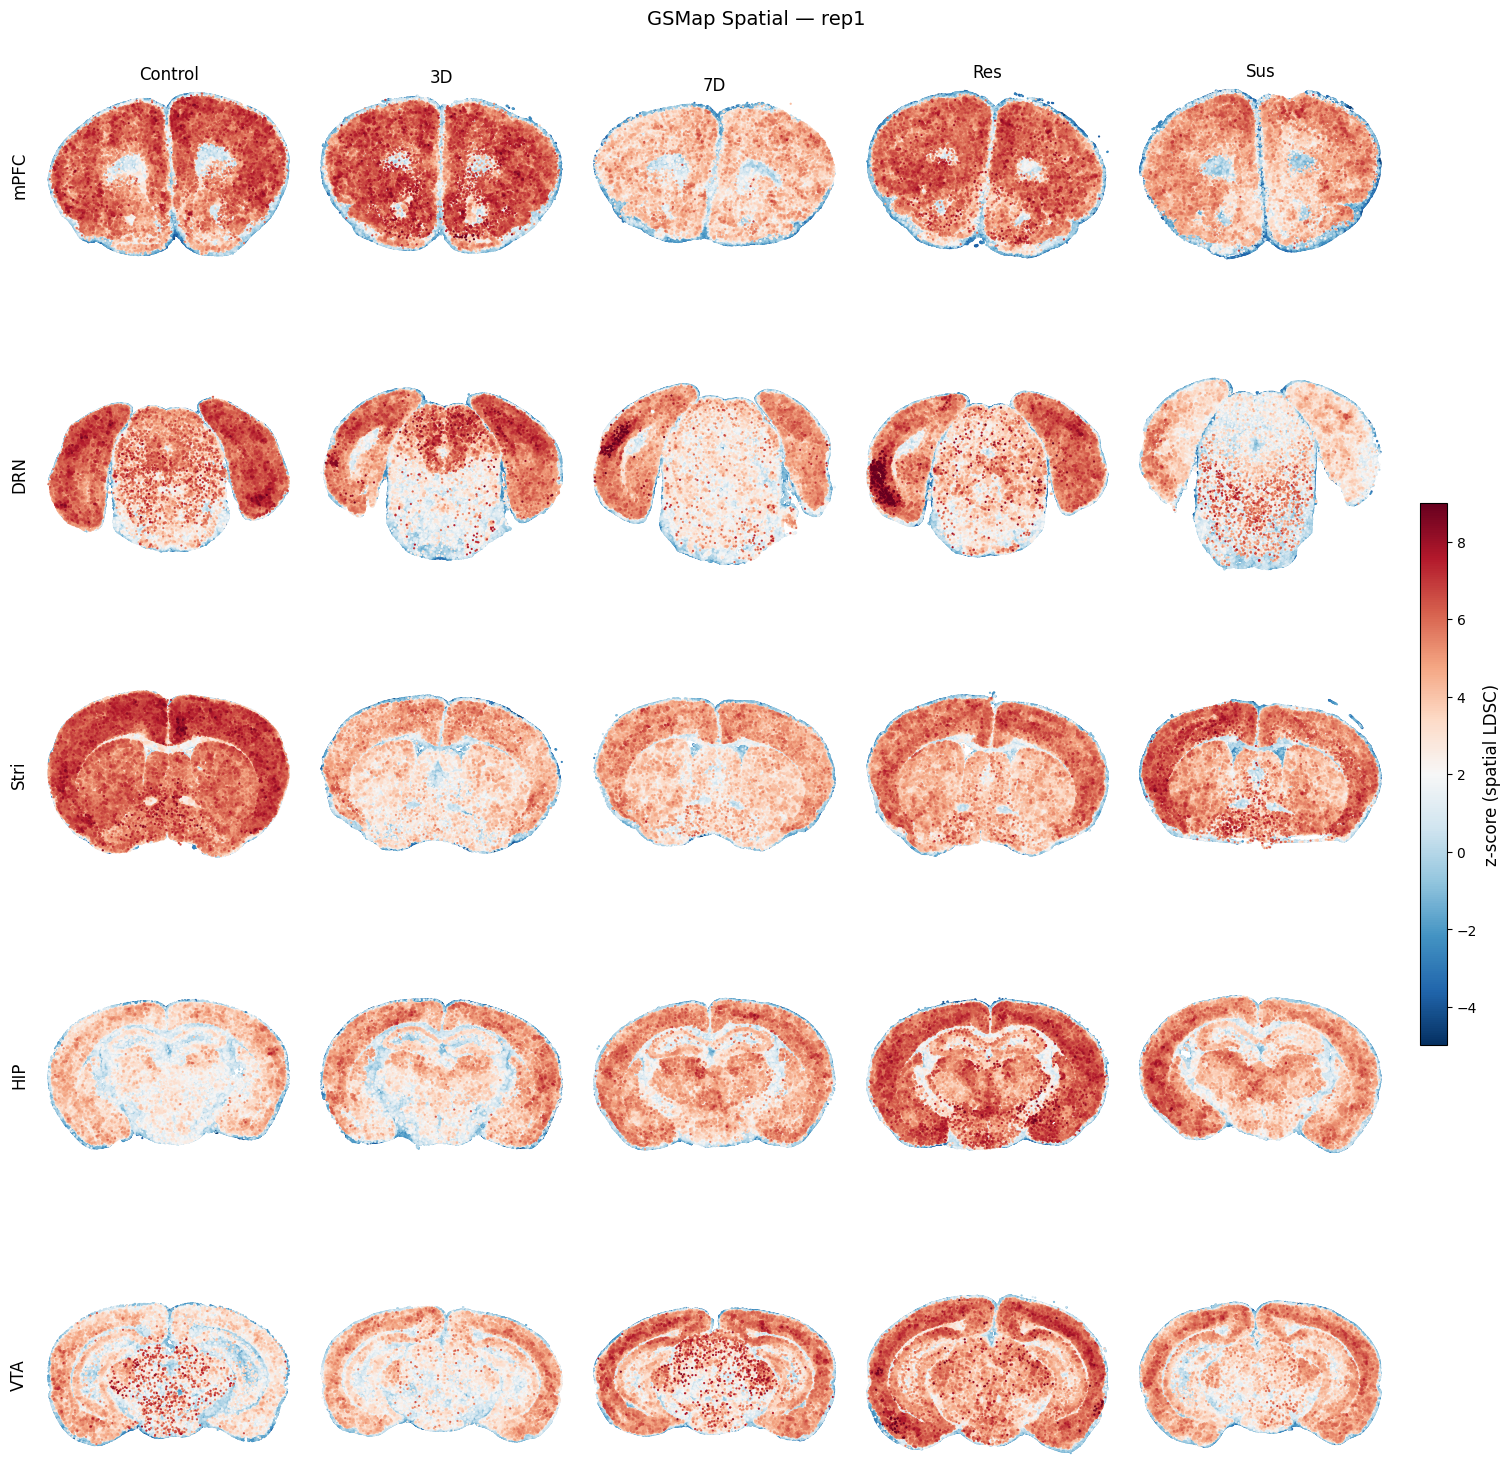

Saved: gsmap_5x5_spatial_rep1.png
[rep2] Processing mPFC - Control
[rep2] Processing mPFC - 3D
[rep2] Processing mPFC - 7D
[rep2] Processing mPFC - Res
[rep2] Processing mPFC - Sus
[rep2] Processing DRN - Control
[rep2] Processing DRN - 3D
[rep2] Processing DRN - 7D
[rep2] Processing DRN - Res
[rep2] Processing DRN - Sus
[rep2] Processing Stri - Control
[rep2] Processing Stri - 3D
[rep2] Processing Stri - 7D
[rep2] Processing Stri - Res
[rep2] Processing Stri - Sus
[rep2] Processing HIP - Control
[rep2] Processing HIP - 3D
[rep2] Processing HIP - 7D
[rep2] Processing HIP - Res
[rep2] Processing HIP - Sus
[rep2] Processing VTA - Control
[rep2] Processing VTA - 3D
[rep2] Processing VTA - 7D
[rep2] Processing VTA - Res
[rep2] Processing VTA - Sus


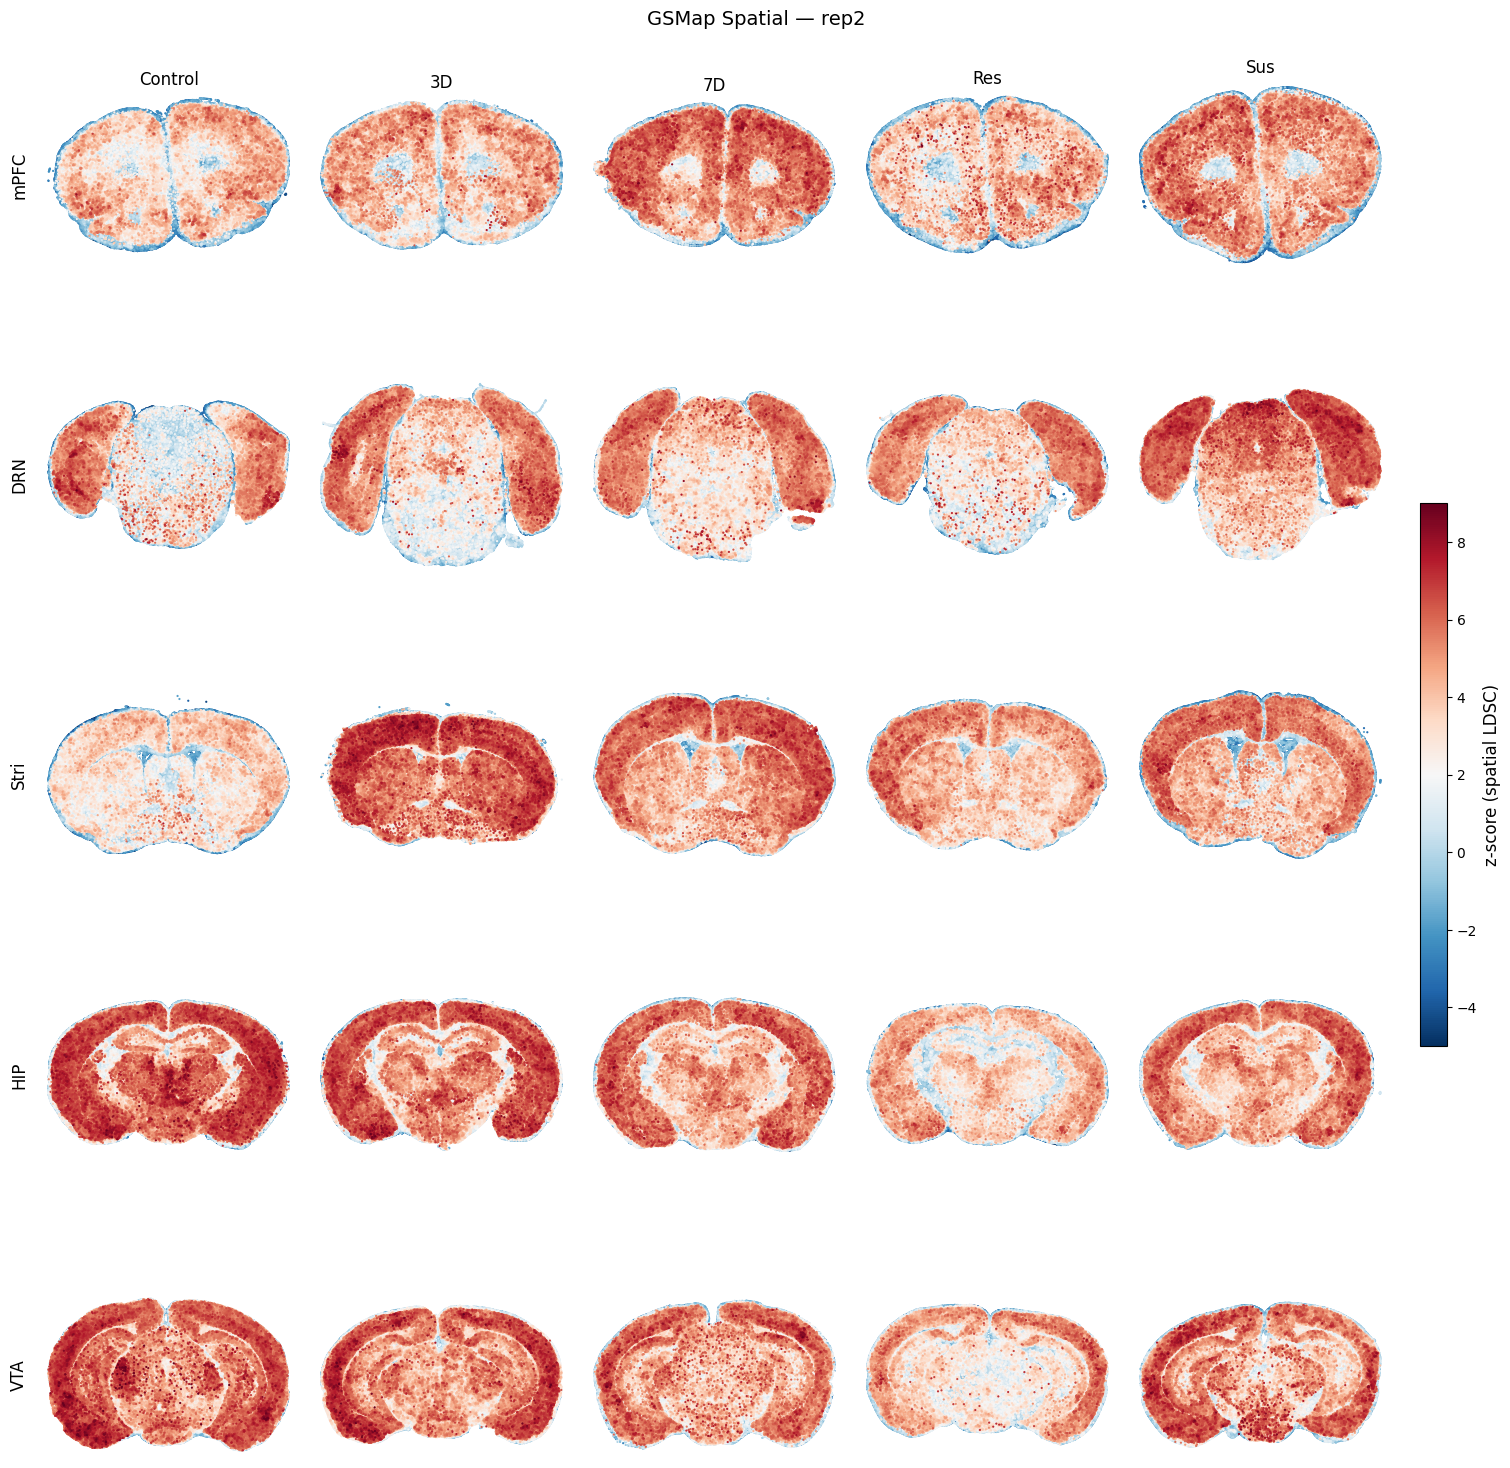

Saved: gsmap_5x5_spatial_rep2.png


In [10]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# =========================
# 参数
# =========================
BASE_DIR = "/biostack/home/suchenyi/gsmap"

REGIONS = ["mPFC", "DRN", "Stri", "HIP", "VTA"]
CONDITIONS = ["Control", "3D", "7D", "Res", "Sus"]
TRAITS = ["MDD"]
REPS = ["rep1", "rep2"]   # ← 分开画

# =========================
# 读取单个 rep 的 LDSC 结果
# =========================
def load_ldsc_single(region, condition, trait, rep):
    path = (
        f"{BASE_DIR}/{region}_{condition}_{rep}/spatial_ldsc/"
        f"{region}_{condition}_{rep}_{trait}.csv.gz"
    )
    if not os.path.exists(path):
        return None

    df = pd.read_csv(path)
    df["spot"] = df["spot"].astype(str)
    return df[["spot", "z"]].rename(columns={"z": "z_mean"})


# =========================
# 对每个 rep 分别画一张 5×5 图
# =========================
for rep in REPS:

    fig, axes = plt.subplots(
        nrows=len(REGIONS),
        ncols=len(CONDITIONS),
        figsize=(15, 15),
        constrained_layout=True,
    )

    for i, region in enumerate(REGIONS):
        for j, condition in enumerate(CONDITIONS):

            ax = axes[i, j]
            print(f"[{rep}] Processing {region} - {condition}")

            # 读取 h5ad（用当前 rep）
            h5ad_path = (
                f"{BASE_DIR}/{region}_{condition}_{rep}/"
                f"{region}_{condition}_{rep}_annotated.h5ad"
            )

            if not os.path.exists(h5ad_path):
                print(f"  Missing: {h5ad_path}")
                ax.axis("off")
                continue

            adata = sc.read_h5ad(h5ad_path)
            adata.obs.index = adata.obs.index.astype(str)

            # 读取 z-score
            trait_series = []
            for trait in TRAITS:
                df_ldsc = load_ldsc_single(region, condition, trait, rep)
                if df_ldsc is None:
                    continue
                trait_series.append(df_ldsc.set_index("spot")["z_mean"])

            if not trait_series:
                ax.axis("off")
                continue

            z_all = pd.concat(trait_series, axis=1)
            z_all["z"] = z_all.mean(axis=1)

            # spot 对齐
            adata.obs["spot_clean"] = (
                adata.obs.index.str.replace("-1", "", regex=False)
            )
            adata.obs = adata.obs.merge(
                z_all[["z"]],
                left_on="spot_clean",
                right_index=True,
                how="left"
            )

            adata = adata[~adata.obs["z"].isna()].copy()

            if adata.n_obs == 0:
                ax.axis("off")
                continue

            if "spatial" not in adata.obsm.keys():
                ax.axis("off")
                continue

            # 坐标处理
            coords = adata.obsm["spatial"].copy().astype(float)
            center = coords.mean(axis=0)
            coords = -(coords - center) + center
            coords[:, 0] -= coords[:, 0].min()
            coords[:, 1] -= coords[:, 1].min()
            adata.obsm["X_spatial_temp"] = coords

            # 绘图
            sc.pl.embedding(
                adata,
                basis="X_spatial_temp",
                color="z",
                color_map="RdBu_r",
                vmin=-5,
                vmax=9,
                size=10,
                ax=ax,
                show=False,
                colorbar_loc=None,
                title="",
            )

            for text in ax.texts:
                if text.get_text() == "z":
                    text.remove()

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel("")
            ax.set_ylabel("")
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_aspect("equal")
            ax.invert_yaxis()

            if i == 0:
                ax.set_title(condition, fontsize=12, pad=4)
            if j == 0:
                ax.set_ylabel(region, fontsize=12, labelpad=6)

    # 全局 colorbar
    norm = mcolors.Normalize(vmin=-5, vmax=9)
    sm = cm.ScalarMappable(cmap="RdBu_r", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.02, shrink=0.6, pad=0.02)
    cbar.set_label("z-score (spatial LDSC)", fontsize=12)

    fig.suptitle(f"GSMap Spatial — {rep}", fontsize=14, y=1.01)

    # 每个 rep 保存为独立文件
    out_path = f"gsmap_5x5_spatial_{rep}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

Processing mPFC - Control


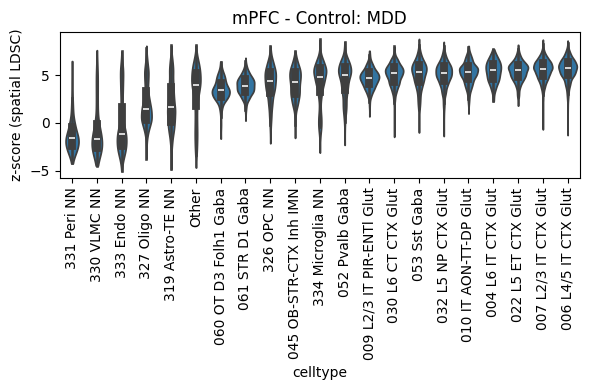

Control | SST vs Others: p = 1.510e-73
Processing mPFC - Sus


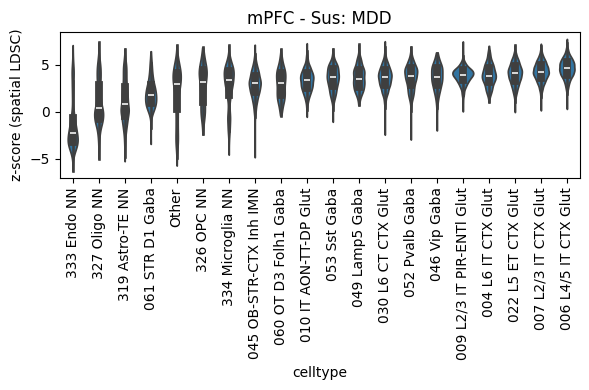

Sus | SST vs Others: p = 6.259e-23
Processing mPFC - Res


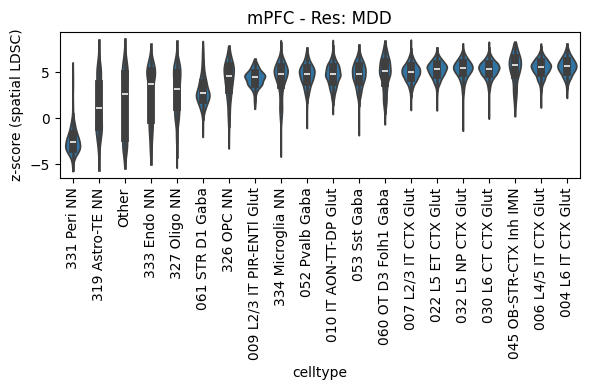

Res | SST vs Others: p = 1.027e-22
Processing mPFC - 3D


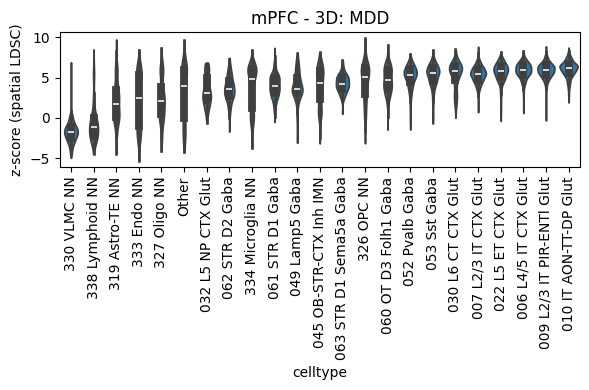

3D | SST vs Others: p = 1.130e-50
Processing mPFC - 7D


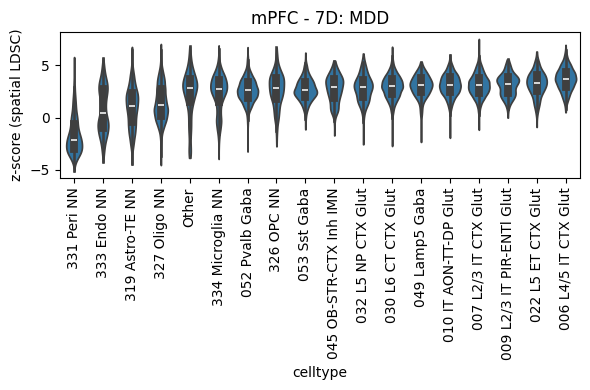

7D | SST vs Others: p = 1.972e-15


In [13]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ranksums

def load_ldsc(region, condition, trait):
    dfs = []
    for rep in ["rep1", "rep2"]:
        file_path = f"/biostack/home/suchenyi/gsmap/{region}_{condition}_{rep}/spatial_ldsc/{region}_{condition}_{rep}_{trait}.csv.gz"
        if not os.path.exists(file_path):
            continue

        df = pd.read_csv(file_path)
        df["spot"] = df["spot"].astype(str)
        df = df[["spot", "z"]].rename(columns={"z": f"z_{rep}"})
        dfs.append(df)

    if len(dfs) == 0:
        return None

    df_merge = dfs[0]
    for df in dfs[1:]:
        df_merge = df_merge.merge(df, on="spot", how="outer")

    z_cols = [c for c in df_merge.columns if "z_" in c]
    df_merge["z"] = df_merge[z_cols].mean(axis=1)

    return df_merge[["spot", "z"]]

def analyze_celltype_z(region, condition, trait="MDD"):

    print(f"Processing {region} - {condition}")

    h5ad_path = f"/biostack/home/suchenyi/gsmap/{region}_{condition}_rep1/{region}_{condition}_rep1_annotated.h5ad"
    if not os.path.exists(h5ad_path):
        return None

    adata = sc.read_h5ad(h5ad_path)
    adata.obs.index = adata.obs.index.astype(str)
    adata.obs["spot_clean"] = adata.obs.index.str.replace("-1", "", regex=False)

    df_ldsc = load_ldsc(region, condition, trait)
    if df_ldsc is None:
        return None

    df = adata.obs.merge(
        df_ldsc,
        left_on="spot_clean",
        right_on="spot",
        how="inner"
    )

    if df.empty:
        return None

    # ===== 提取细胞类型
    df["celltype"] = df["predicted_labels_plot"]

    return df[["celltype", "z"]]

REGION = "mPFC"
TRAIT = "MDD"
CONDITIONS = ["Control", "Sus", "Res","3D","7D"]

for condition in CONDITIONS:

    df = analyze_celltype_z(REGION, condition, TRAIT)
    if df is None:
        continue


    mask = df["celltype"].str.contains("Sst|Pvalb|Vip", case=False, na=False)
    df_sub = df.copy()
    #df_sub = df[mask].copy()
        #只保留 GABA interneuron

    if df_sub.empty:
        continue

    # ===== 画图
    plt.figure(figsize=(6,4))
    order = df.groupby("celltype")["z"].mean().sort_values().index


    sns.violinplot(
        data=df_sub,
        x="celltype",
        y="z",
        inner="box",
        cut=0,
        order=order
    )

    plt.title(f"{REGION} - {condition}: {TRAIT}")
    plt.xticks(rotation=90)
    plt.ylabel("z-score (spatial LDSC)")
    plt.tight_layout()

    plt.savefig(f"{REGION}_{condition}_violin.png", dpi=300)
    plt.show()

    # ===== 统计检验（SST vs others）
    if "Sst" in "".join(df_sub["celltype"].unique()):

        sst = df_sub[df_sub["celltype"].str.contains("Sst")]["z"]
        others = df_sub[~df_sub["celltype"].str.contains("Sst")]["z"]

        stat, p = ranksums(sst, others)

        print(f"{condition} | SST vs Others: p = {p:.3e}")

Filtering cell types with complete data across 5 conditions...
Filtered 15 cell types with complete data (out of 21)
Plotting MDD - Page 1/1


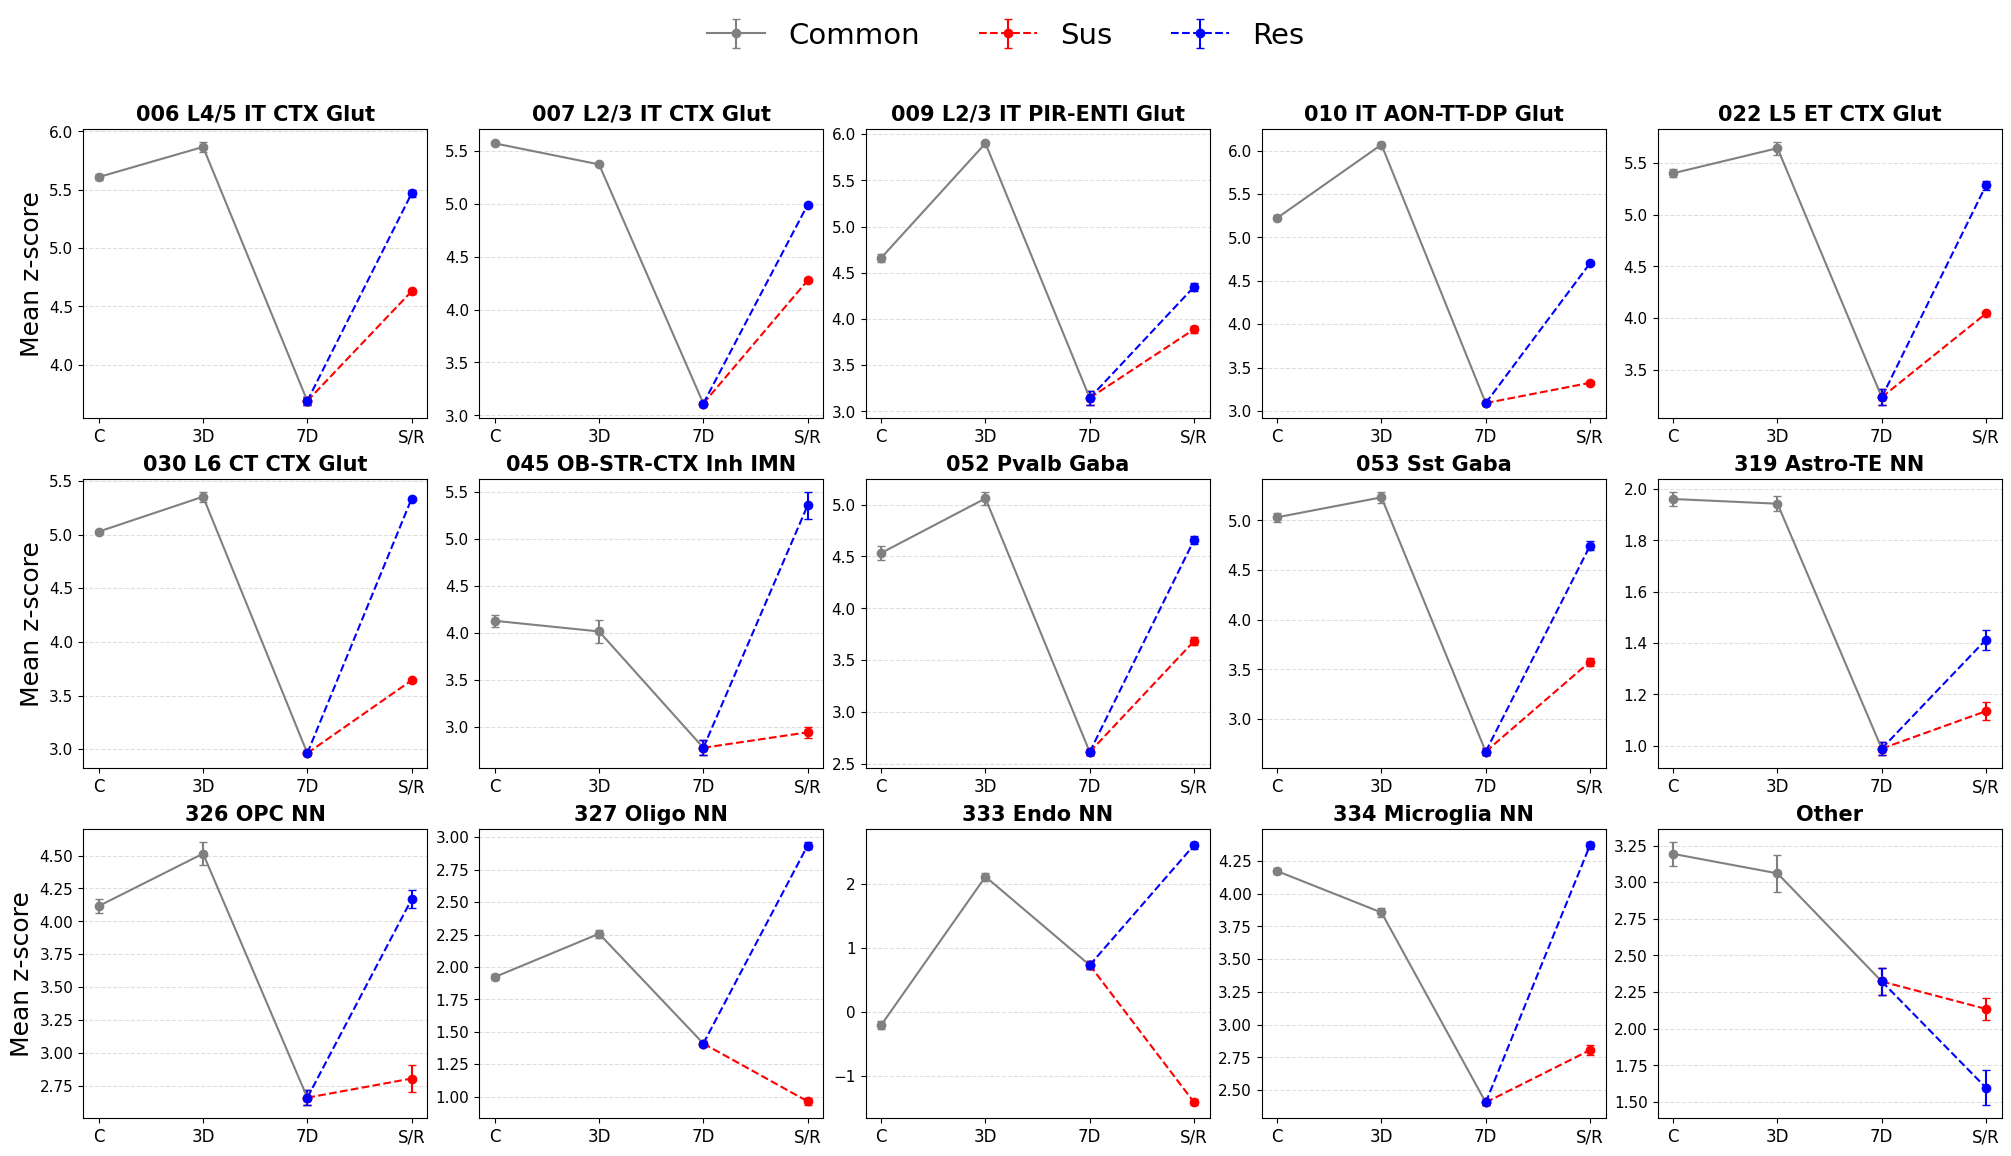

  Saved: /biostack/home/suchenyi/graduate/gsmap/visual/trajectory_plots/combined_MDD_page1.png

=== All Trajectory Panels Done! ===


In [2]:
import os
import re
import math
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

def sanitize_filename(filename):
    """清理文件名中的非法字符"""
    illegal_chars = r'[<>:"/\\|?*]'
    filename = re.sub(illegal_chars, '_', filename)
    filename = filename.replace(' ', '_')
    filename = re.sub(r'[^\w\-_.]', '_', filename)
    if len(filename) > 200:
        filename = filename[:200]
    return filename

# 路径配置
BASE_DIR = "/biostack/home/suchenyi/gsmap"
REGION = "mPFC"
#TRAITS_TO_PLOT = ['SePa','E-Smoking','CoPe','SCZ','IQ']
TRAITS_TO_PLOT = ['MDD']
output_dir = "/biostack/home/suchenyi/graduate/gsmap/visual/trajectory_plots"
os.makedirs(output_dir, exist_ok=True)

def load_ldsc(region, condition, trait):
    """加载LDSC结果，合并rep1和rep2"""
    dfs = []
    for rep in ["rep1", "rep2"]:
        file_path = f"{BASE_DIR}/{region}_{condition}_{rep}/spatial_ldsc/{region}_{condition}_{rep}_{trait}.csv.gz"
        if not os.path.exists(file_path):
            continue
        df = pd.read_csv(file_path)
        df["spot"] = df["spot"].astype(str)
        df = df[["spot", "z"]].rename(columns={"z": f"z_{rep}"})
        dfs.append(df)

    if len(dfs) == 0:
        return None

    df_merge = dfs[0]
    for df in dfs[1:]:
        df_merge = df_merge.merge(df, on="spot", how="outer")

    z_cols = [c for c in df_merge.columns if "z_" in c]
    df_merge["z"] = df_merge[z_cols].mean(axis=1)
    return df_merge[["spot", "z"]]

def get_celltype_z(region, condition, trait="MDD", cell_keyword=""):
    """获取特定细胞类型的z-score值"""
    h5ad_path = f"{BASE_DIR}/{region}_{condition}_rep1/{region}_{condition}_rep1_annotated.h5ad"
    if not os.path.exists(h5ad_path):
        return None

    adata = sc.read_h5ad(h5ad_path)
    adata.obs.index = adata.obs.index.astype(str)
    adata.obs["spot_clean"] = adata.obs.index.str.replace("-1", "", regex=False)

    df_ldsc = load_ldsc(region, condition, trait)
    if df_ldsc is None:
        return None

    df = adata.obs.merge(
        df_ldsc,
        left_on="spot_clean",
        right_on="spot",
        how="inner"
    )

    if df.empty:
        return None

    df["celltype"] = df["predicted_labels_plot"]
    mask = df["celltype"] == cell_keyword
    df_filtered = df[mask]

    if df_filtered.empty:
        return None

    return df_filtered["z"].values

# 1. 动态加载所有初步的细胞类型
sample_h5ad_path = f"{BASE_DIR}/{REGION}_Control_rep1/{REGION}_Control_rep1_annotated.h5ad"
if os.path.exists(sample_h5ad_path):
    sample_adata = sc.read_h5ad(sample_h5ad_path)
    raw_celltypes = sample_adata.obs["predicted_labels_plot"].unique().tolist()
else:
    print("Critical Error: Sample H5AD not found!")
    exit()

# 2. 预筛选：只保留 5 个时间点都有数据的 celltype
print("Filtering cell types with complete data across 5 conditions...")
ALL_CONDITIONS = ["Control", "3D", "7D", "Sus", "Res"]
CELLTYPES_TO_PLOT = []

for ct in raw_celltypes:
    is_complete = True
    for cond in ALL_CONDITIONS:
        # 只要有一个点拿不到数据，就标记为不完整
        z_vals = get_celltype_z(REGION, cond, trait=TRAITS_TO_PLOT[0], cell_keyword=ct)
        if z_vals is None or len(z_vals) == 0:
            is_complete = False
            break
    if is_complete:
        CELLTYPES_TO_PLOT.append(ct)

CELLTYPES_TO_PLOT.sort()
print(f"Filtered {len(CELLTYPES_TO_PLOT)} cell types with complete data (out of {len(raw_celltypes)})")

# 3. 绘图参数配置
COLS = 5
ROWS = 3
SUBPLOTS_PER_PAGE = COLS * ROWS
TIME_MAP = {"Control": 0, "3D": 1, "7D": 2, "Final": 3}

for current_trait in TRAITS_TO_PLOT:
    safe_trait = sanitize_filename(current_trait)
    total_celltypes = len(CELLTYPES_TO_PLOT)
    num_pages = math.ceil(total_celltypes / SUBPLOTS_PER_PAGE)
    
    for page in range(num_pages):
        start_idx = page * SUBPLOTS_PER_PAGE
        end_idx = min(start_idx + SUBPLOTS_PER_PAGE, total_celltypes)
        page_celltypes = CELLTYPES_TO_PLOT[start_idx:end_idx]
        
        fig, axes = plt.subplots(ROWS, COLS, figsize=(4 * COLS, 3.5 * ROWS), constrained_layout=True)
        # 处理只有一行或一列的情况
        if total_celltypes == 1:
            axes_flat = [axes]
        else:
            axes_flat = axes.flatten()
        
        print(f"Plotting {current_trait} - Page {page+1}/{num_pages}")

        for i, current_celltype_keyword in enumerate(page_celltypes):
            ax = axes_flat[i]
            
            # 设置刻度
            ax.set_xticks([0, 1, 2, 3])
            ax.set_xticklabels(["C", "3D", "7D", "S/R"],fontsize=12)
            ax.tick_params(axis='y', labelsize=11)
            records = []
            # 此时已知 5 个点都有数据，直接提取
            for cond in ALL_CONDITIONS:
                z_vals = get_celltype_z(REGION, cond, trait=current_trait, cell_keyword=current_celltype_keyword)
                group = "Shared" if cond in ["Control", "3D", "7D"] else cond
                time_label = "Final" if cond in ["Sus", "Res"] else cond
                records.append({
                    "group": group, 
                    "time": time_label, 
                    "mean_z": np.mean(z_vals), 
                    "sem": np.std(z_vals)/np.sqrt(len(z_vals))
                })

            df_plot = pd.DataFrame(records)
            
            # 绘制 Common Path (C -> 3D -> 7D)
            shared = df_plot[df_plot["group"] == "Shared"].set_index("time").loc[["Control", "3D", "7D"]]
            ax.errorbar([TIME_MAP[t] for t in shared.index], shared["mean_z"], 
                        yerr=shared["sem"], fmt='o-', color='gray', label='Common', capsize=3)

            # 绘制分支 (7D -> Sus 和 7D -> Res)
            val_7d = shared.loc["7D"]
            
            # Sus
            sus_val = df_plot[df_plot["group"] == "Sus"].iloc[0]
            ax.errorbar([TIME_MAP["7D"], TIME_MAP["Final"]], [val_7d["mean_z"], sus_val["mean_z"]],
                        yerr=[val_7d["sem"], sus_val["sem"]], fmt='o--', color='red', label='Sus', capsize=3)
            
            # Res
            res_val = df_plot[df_plot["group"] == "Res"].iloc[0]
            ax.errorbar([TIME_MAP["7D"], TIME_MAP["Final"]], [val_7d["mean_z"], res_val["mean_z"]],
                        yerr=[val_7d["sem"], res_val["sem"]], fmt='o--', color='blue', label='Res', capsize=3)

            ax.set_title(f"{current_celltype_keyword}", fontsize=15, fontweight='bold')
            if i % COLS == 0:
                ax.set_ylabel("Mean z-score",fontsize=18)
            ax.grid(axis='y', linestyle='--', alpha=0.4)

        # 移除多余空白子图
        for j in range(i + 1, len(axes_flat)):
            fig.delaxes(axes_flat[j])

        # 全局图例
        handles, labels = axes_flat[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3, frameon=False,fontsize=21)

        save_path = os.path.join(output_dir, f"combined_{safe_trait}_page{page+1}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"  Saved: {save_path}")

print("\n=== All Trajectory Panels Done! ===")

可检查的 celltype 数量: 15

Celltype                            Rep             Control   3D        7D        Sus       Res     
006 L4/5 IT CTX Glut                rep1            0.812     0.800     0.826     0.857     0.689   
                                    rep2            0.814     0.879     0.792     0.743     0.813   
                                    merged_norm     0.812     0.800     0.826     0.857     0.688   
--------------------------------------------------------------------------------
007 L2/3 IT CTX Glut                rep1            0.796     0.614     0.508     0.713     0.486   
                                    rep2            0.654     0.843     0.672     0.587     0.553   
                                    merged_norm     0.796     0.613     0.507     0.713     0.486   
--------------------------------------------------------------------------------
009 L2/3 IT PIR-ENTl Glut           rep1            0.436     0.813     0.525     0.555     0.217   
        

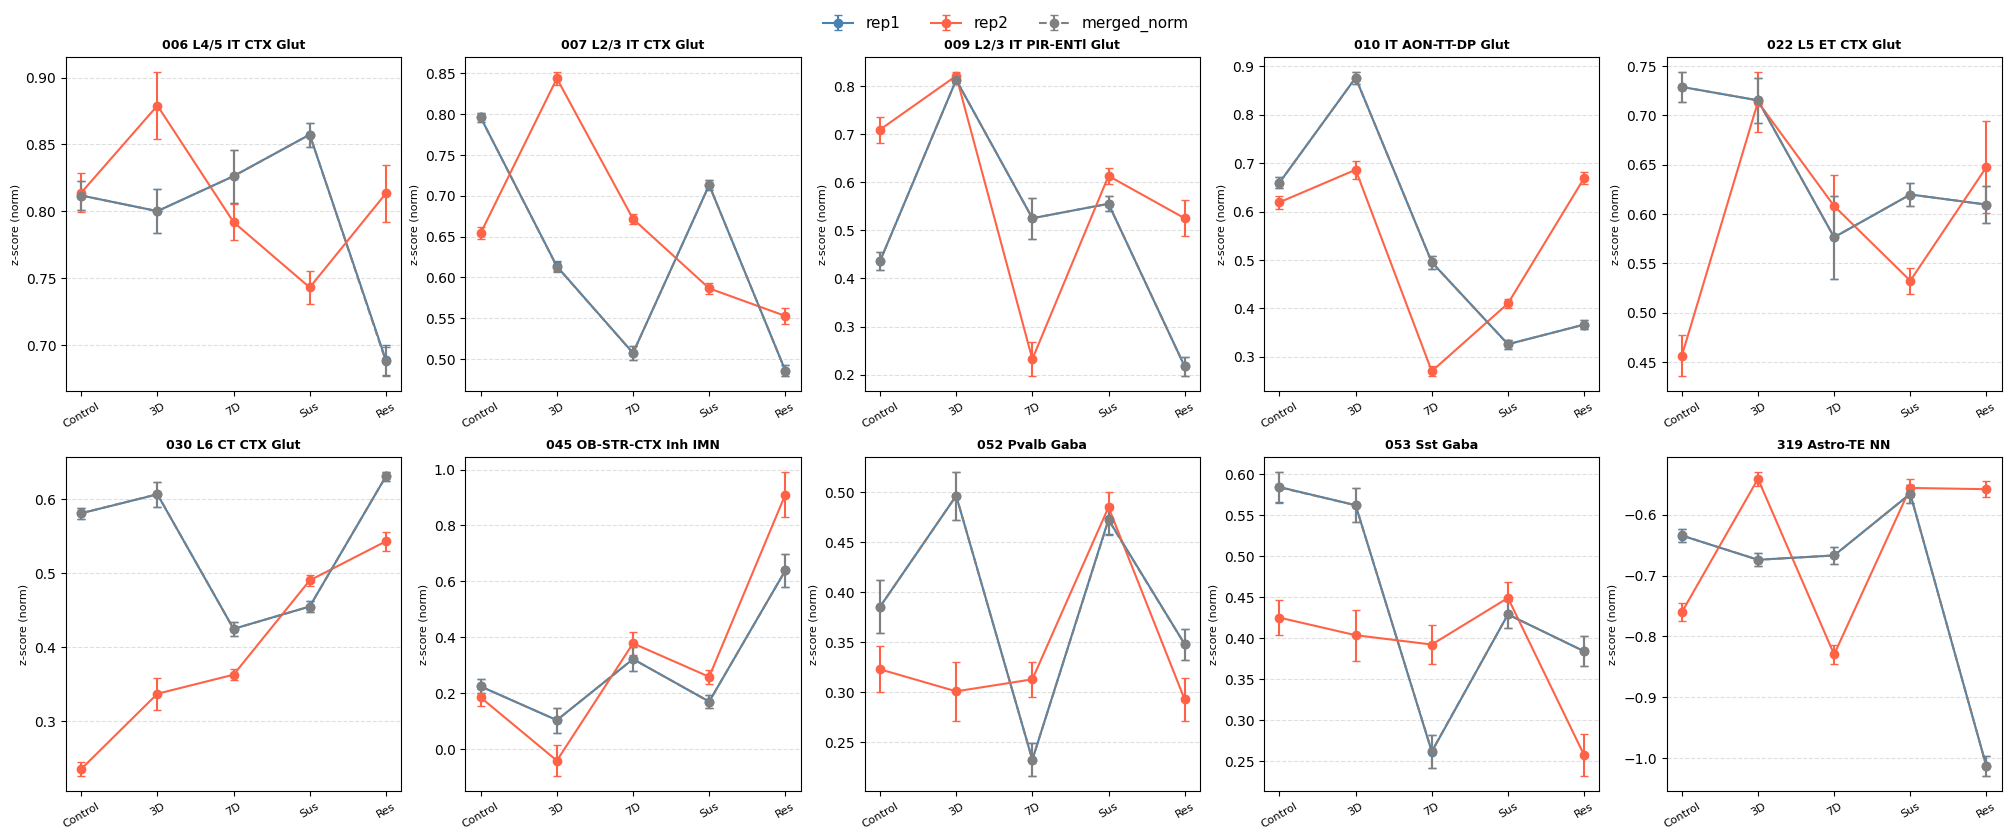


Saved: rep_consistency_check.png


In [14]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

# =========================
# 参数
# =========================
BASE_DIR = "/biostack/home/suchenyi/gsmap"
REGION = "mPFC"
TRAIT = "MDD"
ALL_CONDITIONS = ["Control", "3D", "7D", "Sus", "Res"]

# =========================
# 1. 标准化版 load_ldsc（单 rep）
# =========================
def load_ldsc_single_normalized(region, condition, trait, rep):
    path = f"{BASE_DIR}/{region}_{condition}_{rep}/spatial_ldsc/{region}_{condition}_{rep}_{trait}.csv.gz"
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    df["spot"] = df["spot"].astype(str)
    # 每个 rep 内部标准化
    df["z_norm"] = (df["z"] - df["z"].mean()) / df["z"].std()
    return df[["spot", "z_norm"]].rename(columns={"z_norm": "z"})


def load_ldsc_normalized(region, condition, trait):
    """标准化后合并 rep1 + rep2"""
    dfs = []
    for rep in ["rep1", "rep2"]:
        df = load_ldsc_single_normalized(region, condition, trait, rep)
        if df is None:
            continue
        dfs.append(df.rename(columns={"z": f"z_{rep}"}))

    if not dfs:
        return None

    df_merge = dfs[0]
    for df in dfs[1:]:
        df_merge = df_merge.merge(df, on="spot", how="outer")

    z_cols = [c for c in df_merge.columns if c.startswith("z_")]
    df_merge["z"] = df_merge[z_cols].mean(axis=1)
    return df_merge[["spot", "z"]]


# =========================
# 2. 获取某 celltype 在某 rep 下的 z 值
#    rep="merged_norm" 时使用标准化合并版
# =========================
def get_celltype_z(region, condition, trait, cell_keyword, rep="rep1"):
    if rep == "merged_norm":
        df_ldsc = load_ldsc_normalized(region, condition, trait)
        h5ad_path = f"{BASE_DIR}/{region}_{condition}_rep1/{region}_{condition}_rep1_annotated.h5ad"
    else:
        df_ldsc = load_ldsc_single_normalized(region, condition, trait, rep)
        h5ad_path = f"{BASE_DIR}/{region}_{condition}_{rep}/{region}_{condition}_{rep}_annotated.h5ad"

    if df_ldsc is None or not os.path.exists(h5ad_path):
        return None

    adata = sc.read_h5ad(h5ad_path)
    adata.obs.index = adata.obs.index.astype(str)
    adata.obs["spot_clean"] = adata.obs.index.str.replace("-1", "", regex=False)

    df = adata.obs.merge(df_ldsc, left_on="spot_clean", right_on="spot", how="inner")
    df_filtered = df[df["predicted_labels_plot"] == cell_keyword]

    if df_filtered.empty:
        return None
    return df_filtered["z"].values


# =========================
# 3. 加载所有 celltype
# =========================
sample_h5ad = f"{BASE_DIR}/{REGION}_Control_rep1/{REGION}_Control_rep1_annotated.h5ad"
sample_adata = sc.read_h5ad(sample_h5ad)
raw_celltypes = sample_adata.obs["predicted_labels_plot"].unique().tolist()

# 只保留 rep1 下 5 个时间点都有数据的 celltype
CELLTYPES_TO_CHECK = []
for ct in sorted(raw_celltypes):
    complete = all(
        get_celltype_z(REGION, cond, TRAIT, ct, rep="rep1") is not None
        for cond in ALL_CONDITIONS
    )
    if complete:
        CELLTYPES_TO_CHECK.append(ct)

print(f"可检查的 celltype 数量: {len(CELLTYPES_TO_CHECK)}")

# =========================
# 4. 打印数值对比表：rep1 / rep2 / merged_norm
# =========================
print("\n" + "="*80)
print(f"{'Celltype':<35} {'Rep':<15} " + "  ".join(f"{c:<8}" for c in ALL_CONDITIONS))
print("="*80)

for ct in CELLTYPES_TO_CHECK:
    for rep in ["rep1", "rep2", "merged_norm"]:
        means = []
        for cond in ALL_CONDITIONS:
            z = get_celltype_z(REGION, cond, TRAIT, ct, rep=rep)
            means.append(f"{np.mean(z):.3f}" if z is not None else "  None")
        label = f"{ct[:34]}" if rep == "rep1" else ""
        print(f"{label:<35} {rep:<15} " + "  ".join(f"{m:<8}" for m in means))
    print("-"*80)

# =========================
# 5. 统计趋势一致性（Control→3D→7D 方向）
# =========================
print("\n=== 趋势一致性分析（Control→3D→7D）===")
print(f"{'Celltype':<35} {'rep1 trend':<15} {'rep2 trend':<15} {'一致？'}")
print("-"*75)

consistent = 0
inconsistent = 0
inconsistent_list = []

for ct in CELLTYPES_TO_CHECK:
    trends = {}
    for rep in ["rep1", "rep2"]:
        z_c = get_celltype_z(REGION, "Control", TRAIT, ct, rep)
        z_3d = get_celltype_z(REGION, "3D", TRAIT, ct, rep)
        z_7d = get_celltype_z(REGION, "7D", TRAIT, ct, rep)

        if any(x is None for x in [z_c, z_3d, z_7d]):
            trends[rep] = "N/A"
            continue

        m_c, m_3d, m_7d = np.mean(z_c), np.mean(z_3d), np.mean(z_7d)

        if m_3d > m_c and m_7d < m_3d:
            trends[rep] = "↑ then ↓"
        elif m_3d > m_c and m_7d > m_3d:
            trends[rep] = "↑ ↑"
        elif m_3d < m_c and m_7d < m_3d:
            trends[rep] = "↓ ↓"
        elif m_3d < m_c and m_7d > m_3d:
            trends[rep] = "↓ then ↑"
        else:
            trends[rep] = "flat"

    match = "✓" if trends.get("rep1") == trends.get("rep2") else "✗"
    if match == "✓":
        consistent += 1
    else:
        inconsistent += 1
        inconsistent_list.append(ct)

    print(f"{ct:<35} {trends.get('rep1','N/A'):<15} {trends.get('rep2','N/A'):<15} {match}")

print(f"\n一致: {consistent}  不一致: {inconsistent}  "
      f"一致率: {consistent/(consistent+inconsistent)*100:.1f}%")

# =========================
# 6. 可视化：选前 10 个 celltype，画三条线对比
# =========================
N_PLOT = min(10, len(CELLTYPES_TO_CHECK))
fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)
axes_flat = axes.flatten()

x = [0, 1, 2, 3, 4]
x_labels = ALL_CONDITIONS

for idx, ct in enumerate(CELLTYPES_TO_CHECK[:N_PLOT]):
    ax = axes_flat[idx]

    for rep, color, ls in [("rep1", "steelblue", "-"),
                            ("rep2", "tomato", "-"),
                            ("merged_norm", "gray", "--")]:
        means, sems = [], []
        for cond in ALL_CONDITIONS:
            z = get_celltype_z(REGION, cond, TRAIT, ct, rep)
            if z is not None:
                means.append(np.mean(z))
                sems.append(np.std(z) / np.sqrt(len(z)))
            else:
                means.append(np.nan)
                sems.append(np.nan)

        ax.errorbar(x, means, yerr=sems, fmt=f"o{ls}",
                    color=color, label=rep, capsize=3)

    ax.set_title(ct, fontsize=9, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=8, rotation=30)
    ax.set_ylabel("z-score (norm)", fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

# 全局图例
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           bbox_to_anchor=(0.5, 1.04), ncol=3, frameon=False, fontsize=11)

plt.savefig("rep_consistency_check.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: rep_consistency_check.png")